## Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Functions

### Get traffic data

In [24]:
def get_traffic_data():
    # Direct link to the raw CSV
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/Metro_Interstate_Traffic_Volume.csv.gz"
    
    # Load data (pandas handles the .gz compression automatically)
    df = pd.read_csv(url)
    
    # 1. Convert timestamp to datetime and extract time-based features
    # These are critical "hidden" sensors for traffic
    df['date_time'] = pd.to_datetime(df['date_time'])
    df['hour'] = df['date_time'].dt.hour
    df['day_of_week'] = df['date_time'].dt.dayofweek
    
    # 2. Binary Target: 1 if traffic_volume > 4500 (Heavy), else 0
    # 4500 is a standard threshold for "congested" on this specific road
    df['is_heavy'] = (df['traffic_volume'] > 4500).astype(int)
    
    # 3. Clean up Categorical Weather (One-Hot Encoding)
    # This turns 'Rain', 'Snow', 'Clouds' into transparent 0/1 columns
    df = pd.get_dummies(df, columns=['weather_main'], prefix='w')
    
    # 4. Final Selection of Features for XAI
    features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week'] + \
               [c for c in df.columns if c.startswith('w_')]
    
    df_final = df[features + ['is_heavy']]
    return df_final, features


In [22]:
df_final = get_encoded_air_quality()
print("Columns after One-Hot Encoding:")
print(df_final.columns.tolist())

KeyError: 'pollution'

### Traffic Data Pipeline

In [28]:
from sklearn.preprocessing import MinMaxScaler

class TrafficDataPipeline:
    def __init__(self, window_size=24):
        self.window_size = window_size
        self.scaler = MinMaxScaler()
        self.feature_names = None

    def fit_transform(self, df):
        # Separate Features and Target
        y_raw = df['is_heavy'].values
        X_raw = df.drop(columns=['is_heavy'])
        self.feature_names = X_raw.columns.tolist()

        # Scale the numerical data (0 to 1)
        X_scaled = self.scaler.fit_transform(X_raw)

        # Create the 3D Windows (The 'Chopping')
        X_3d, y_3d = [], []
        for i in range(len(X_scaled) - self.window_size):
            X_3d.append(X_scaled[i : i + self.window_size])
            y_3d.append(y_raw[i + self.window_size])
            
        return np.array(X_3d), np.array(y_3d)

    def inverse_transform_features(self, scaled_window):
        """Useful for XAI to show real values (Celsius, Hours) instead of 0-1"""
        return self.scaler.inverse_transform(scaled_window)

### Build XAI Traffic Model

In [31]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_xai_traffic_model(input_shape):
    """
    input_shape: (24, num_features) 
    24 time steps (hours) and your encoded features.
    """
    model = models.Sequential([
        # THE INPUT: The 24-hour 'block'
        layers.Input(shape=input_shape),

        # FEATURE EXTRACTION: Detecting Local Patterns
        # Layer 1: 64 filters to catch basic 'shapes' in the data
        layers.Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        
        # Layer 2: 128 filters to find more complex relationships 
        # (e.g., 'Cold Temp' occurring at '8 AM')
        layers.Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        
        # THE XAI BRIDGE: Global Average Pooling (GAP)
        # This collapses the 24 hours into 128 average 'scores'.
        # Vital for Grad-CAM because it keeps the feature maps interpretable.
        layers.GlobalAveragePooling1D(),

        # DECISION HEAD: The final reasoning
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3), # Helps the model generalize (not just memorize)
        layers.Dense(1, activation='sigmoid') # Binary Output: 0 (Light) or 1 (Heavy)
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## Getting Data

In [25]:
df_traffic, traffic_features = get_traffic_data()
print(f"Dataset Loaded: {df_traffic.shape[0]} rows (hours).")
print(df_traffic.head())

Dataset Loaded: 48204 rows (hours).
     temp  rain_1h  snow_1h  clouds_all  hour  day_of_week  w_Clear  w_Clouds  \
0  288.28      0.0      0.0          40     9            1    False      True   
1  289.36      0.0      0.0          75    10            1    False      True   
2  289.58      0.0      0.0          90    11            1    False      True   
3  290.13      0.0      0.0          90    12            1    False      True   
4  291.14      0.0      0.0          75    13            1    False      True   

   w_Drizzle  w_Fog  w_Haze  w_Mist  w_Rain  w_Smoke  w_Snow  w_Squall  \
0      False  False   False   False   False    False   False     False   
1      False  False   False   False   False    False   False     False   
2      False  False   False   False   False    False   False     False   
3      False  False   False   False   False    False   False     False   
4      False  False   False   False   False    False   False     False   

   w_Thunderstorm  is_heavy  
0 

## Transforming Data

In [32]:
pipeline = TrafficDataPipeline(window_size=24)
X_final, y_final = pipeline.fit_transform(df_traffic)

print(f"Pipeline complete! Input shape: {X_final.shape}")
print(f"Target shape: {y_final.shape}")

Pipeline complete! Input shape: (48180, 24, 17)
Target shape: (48180,)


## Training the model

In [33]:
input_shape = (X_final.shape[1], X_final.shape[2]) 
model = build_xai_traffic_model(input_shape)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 24, 64)         │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 24, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,121 (145.00 KB)

 Trainable params: 36,737 (143.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [34]:
from sklearn.model_selection import train_test_split

# 1. Create the 'Final Exam' (Test Set)
# We take 20% of the data and lock it in a vault.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_final, y_final, test_size=0.2, shuffle=False
)

# 2. Create the 'Practice Quiz' (Validation Set)
# From the remaining 80%, we take another 20% for validation.
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, shuffle=False
)

# 3. Train and Validate
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val), # The Practice Quiz
    verbose=1
)

# 4. The Final Exam Score
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Final Exam (Test) Accuracy: {test_acc*100:.2f}%")

Epoch 1/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7522 - loss: 0.4899 - val_accuracy: 0.8218 - val_loss: 0.3692
Epoch 2/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8574 - loss: 0.3238 - val_accuracy: 0.8943 - val_loss: 0.2627
Epoch 3/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8727 - loss: 0.2924 - val_accuracy: 0.8766 - val_loss: 0.2789
Epoch 4/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8784 - loss: 0.2773 - val_accuracy: 0.9119 - val_loss: 0.2181
Epoch 5/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8846 - loss: 0.2648 - val_accuracy: 0.9139 - val_loss: 0.2235
Epoch 6/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8926 - loss: 0.2484 - val_accuracy: 0.9137 - val_loss: 0.2193
Epoch 7/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8958 - loss: 0.2389 - val_accuracy: 0.9010 - val_loss: 0.2361
Epoch 8/20
964/964 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8979 - loss: 0.2344 - val_accuracy: 0.

## Model Performance Evaluation

302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 931us/step


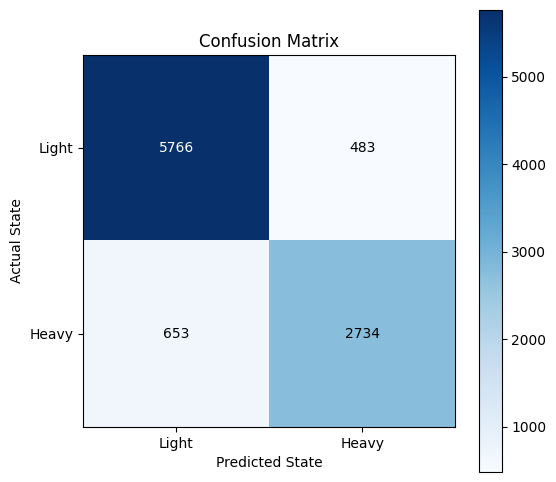

In [35]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report


# Get model predictions
y_pred_probs = model.predict(X_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

# --- CONFUSION MATRIX (Manual Heatmap) ---
cm = confusion_matrix(y_test, y_pred)
classes = ['Light', 'Heavy']

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Set labels and ticks
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=classes, yticklabels=classes,
       title='Confusion Matrix',
       ylabel='Actual State',
       xlabel='Predicted State')

# Loop over data dimensions and create text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.show()

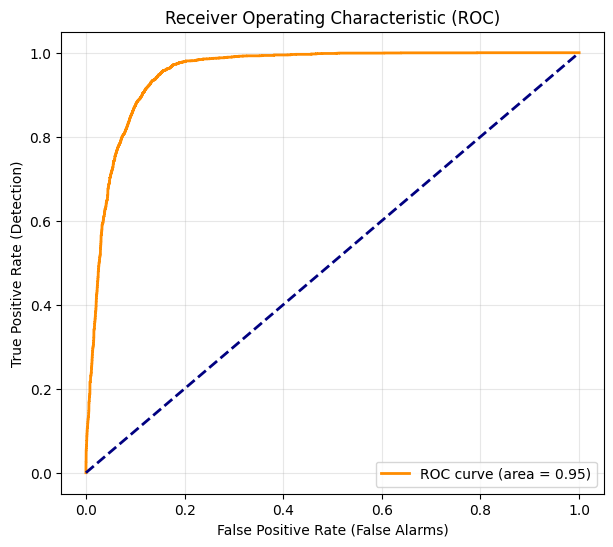


--- Classification Report ---
              precision    recall  f1-score   support

       Light       0.90      0.92      0.91      6249
       Heavy       0.85      0.81      0.83      3387

    accuracy                           0.88      9636
   macro avg       0.87      0.86      0.87      9636
weighted avg       0.88      0.88      0.88      9636



In [36]:
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Detection)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 2. Detailed Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=classes))

## Exploration